# 05 · Profile-conditioned questions

**Why this matters.** A solo business traveller, a couple on a city break and a family of four look at the same bathtub photo with different questions in mind. The search page already knows who is searching. The guest selector sets the number of adults and children, and trip-type filters cover business, leisure, couple and group travel. So the questions can follow the traveller instead of being one generic list.

| What the user selects on the search page | Profile used for generation |
|---|---|
| 1 adult | **single**: solo traveller |
| 2 adults, or the "couple" trip type | **couple**: two people travelling together |
| 3 or more guests, children, or the "group" trip type | **group**: large group or family |

The business / leisure trip type is a natural next signal to add on top.

One Gemini 3.0 Pro call per detection returns three questions for each profile, nine in total. A single call keeps the three sets consistent with each other and avoids three separate API calls.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from amenity_qgen import config, plotting
from amenity_qgen.plotting import SERIES, MUTED, TEXT, TEXT_2

plotting.use_style()
pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "results" / "figures"
AMENITIES = ["bathtub", "kettle", "hairdryer", "mirror", "tv"]
NAMES = {"bathtub": "Bathtub", "kettle": "Kettle", "hairdryer": "Hairdryer", "mirror": "Mirror", "tv": "TV"}

In [2]:
from amenity_qgen.prompts import build_profile_prompt, PROFILE_EXAMPLES
print(build_profile_prompt("bathtub"))

You are an AI assistant helping travelers make hotel booking decisions on Trivago.

Generate 3 questions about this bathtub for EACH of these 3 user perspectives:

1. **SOLO TRAVELER**: Questions focused on individual use and convenience
2. **COUPLE**: Questions about suitability for two people traveling together
3. **GROUP/FAMILY**: Questions about capacity and use by multiple people

**Requirements for ALL questions**:
- Focus on FUNCTIONALITY, SIZE, QUALITY, CAPACITY
- Help travelers DECIDE whether to book
- Use natural, conversational language
- Be specific to what's visible in the image
- Each perspective should have DISTINCT concerns

**Output Format** (EXACTLY like this):
SINGLE:
1. [question]
2. [question]
3. [question]

COUPLE:
1. [question]
2. [question]
3. [question]

GROUP:
1. [question]
2. [question]
3. [question]

Generate the questions now:


In [3]:
pd.DataFrame(PROFILE_EXAMPLES["bathtub"]).rename(columns=str.title)

,Single,Couple,Group
0,Is the bathtub deep enough for a relaxing solo soak?,Is the bathtub spacious enough for two people?,Is there both a tub and shower to accommodate multiple people?
1,Can I easily reach everything I need while bathing alone?,Are there dual controls for water temperature?,How quickly does the tub fill for multiple consecutive uses?
2,Is the tub slip-resistant for safety when showering solo?,Is there enough counter space for both partners' toiletries?,Are there safety features like grab bars for children or elderly?


In [4]:
RUN_GENERATION = False
if RUN_GENERATION:
    from amenity_qgen.generation import get_client, generate_profile_questions
    client = get_client()
    out = generate_profile_questions(client, config.FINAL_MODEL, image_path, box, "kettle")

prof = {am: pd.read_csv(ROOT / "results" / "profiles" / f"questions_{am}_by_profile.csv") for am in AMENITIES}
pd.DataFrame({"detections": {NAMES[a]: len(d) for a, d in prof.items()}, "questions": {NAMES[a]: 9 * len(d) for a, d in prof.items()}}).T

,Bathtub,Kettle,Hairdryer,Mirror,TV
detections,276,183,201,627,267
questions,2484,1647,1809,5643,2403


## Example: one kettle, three travellers

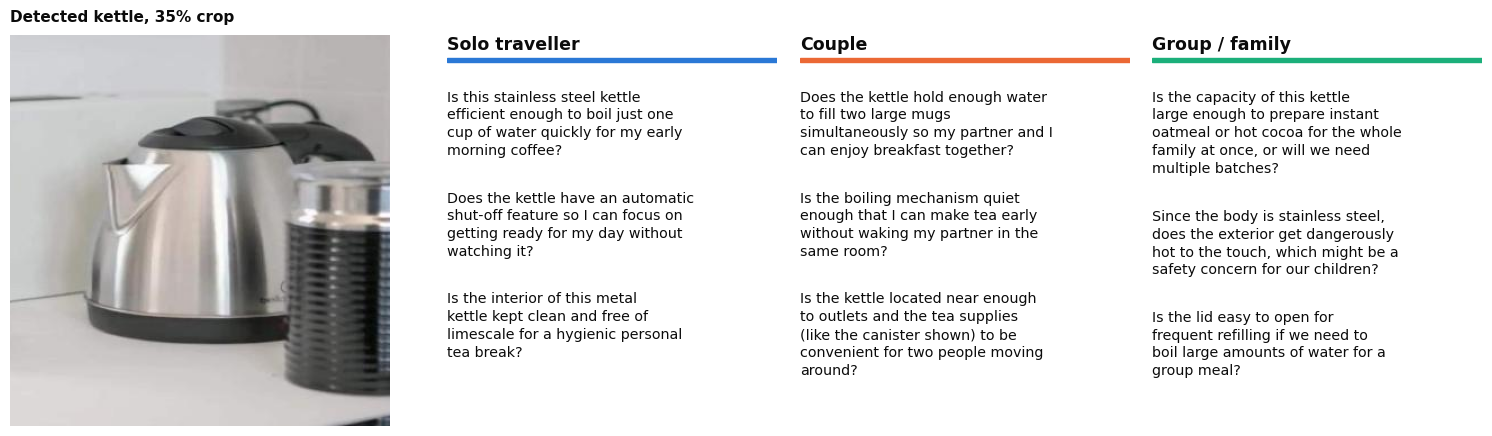

In [5]:
import textwrap
from amenity_qgen.cropping import crop_box, safe_open_image

f = "image_113_jpg.rf.faa92a37eb3a6d1f5f7fe5ee9c1d7571.jpg"
row = prof["kettle"][prof["kettle"].image == f].sort_values("score", ascending=False).iloc[0]
img = safe_open_image(ROOT / "data" / "user_study_images" / f"kettle_{f}")
crop = crop_box(img, [row.x1, row.y1, row.x2, row.y2])

fig = plt.figure(figsize=(15, 4.6))
ax0 = fig.add_axes([0.0, 0.05, 0.27, 0.85]); ax0.imshow(crop); ax0.set_axis_off()
ax0.set_title("Detected kettle, 35% crop", loc="left", fontsize=11)
labels = {"single": "Solo traveller", "couple": "Couple", "group": "Group / family"}
for k, p in enumerate(["single", "couple", "group"]):
    ax = fig.add_axes([0.30 + k * 0.235, 0.05, 0.22, 0.85]); ax.set_axis_off()
    ax.add_patch(plt.Rectangle((0, 0.93), 1, 0.012, color=SERIES[k], transform=ax.transAxes))
    ax.text(0, 1.0, labels[p], fontsize=12.5, fontweight="bold", color=TEXT, va="top", transform=ax.transAxes)
    y = 0.86
    for i in range(1, 4):
        wrapped = textwrap.fill(row[f"gemini_3_{p}_q{i}"], 34)
        ax.text(0, y, wrapped, fontsize=10.3, color=TEXT, va="top", transform=ax.transAxes, linespacing=1.35)
        y -= 0.047 * (wrapped.count("\n") + 1) + 0.07
fig.savefig(FIG / "profile_example_kettle.png"); plt.show()

The solo traveller cares about boiling one cup quickly, the couple about not waking a partner, the family about capacity and a hot metal body around children. Same photo, three different decisions.

## Do the profiles actually change the questions?
Three checks, all on the 13,959 profile questions:
- **Distinctiveness:** 1 minus the cosine similarity between two profiles' question sets (sentence embeddings, all-MiniLM-L6-v2). Higher means the profiles really differ.
- **Profile alignment (0 to 1):** does the question use language that fits its profile ("my own", "both of us", "the kids")?
- **Specificity (0 to 1):** points for quantities, concrete feature terms, a clear question verb, and a length of 10 to 20 words.

Plus the fallback rate from the same quality gate as notebook 04.

In [6]:
from amenity_qgen.quality import fallback_rate, profile_alignment, specificity_score

rows = []
for am in AMENITIES:
    for p in ["single", "couple", "group"]:
        qs = [q for i in range(1, 4) for q in prof[am][f"gemini_3_{p}_q{i}"].dropna()]
        f, n, r = fallback_rate(qs, am, extended=False)
        rows.append(dict(amenity=am, profile=p, questions=n, fallback_rate=r,
                         specificity=np.mean([specificity_score(q) for q in qs]),
                         alignment=np.mean([profile_alignment(q, p) for q in qs]),
                         avg_words=np.mean([len(q.split()) for q in qs])))
pq = pd.DataFrame(rows)
pq.to_csv(ROOT / "results" / "profiles" / "profile_quality.csv", index=False)
pq.pivot(index="amenity", columns="profile", values="fallback_rate").rename(index=NAMES).round(2)

profile,couple,group,single
amenity,,,
Bathtub,1.21,4.95,3.26
Hairdryer,0.66,2.82,0.33
Kettle,1.46,0.00,4.74
Mirror,1.82,1.50,1.01
TV,0.87,1.50,1.37


pair,couple_vs_group,single_vs_couple,single_vs_group
amenity,,,
Bathtub,0.613,0.496,0.612
Kettle,0.652,0.616,0.699
Hairdryer,0.725,0.679,0.710
Mirror,0.569,0.614,0.645
TV,0.604,0.565,0.655


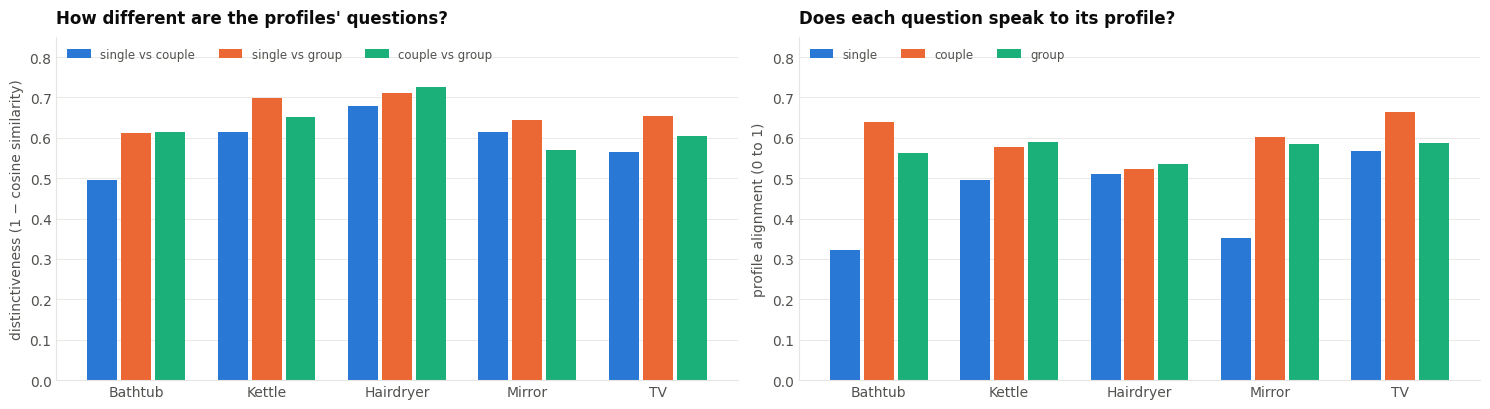

In [7]:
RUN_EMBEDDINGS = False   # needs sentence-transformers
if RUN_EMBEDDINGS:
    from amenity_qgen.quality import load_encoder, profile_distinctiveness

dist = pd.read_csv(ROOT / "results" / "profiles" / "profile_distinctiveness.csv")
display(dist.pivot(index="amenity", columns="pair", values="distinctiveness").loc[AMENITIES].rename(index=NAMES).round(3))

pairs = ["single_vs_couple", "single_vs_group", "couple_vs_group"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.2))
x = np.arange(len(AMENITIES)); w = 0.26
for k, pr in enumerate(pairs):
    v = dist[dist.pair == pr].set_index("amenity").loc[AMENITIES, "distinctiveness"]
    a1.bar(x + (k - 1) * w, v, w - 0.03, color=SERIES[k], label=pr.replace("_", " "))
a1.set_xticks(x); a1.set_xticklabels([NAMES[a] for a in AMENITIES]); a1.set_ylim(0, 0.85); a1.grid(axis="x", visible=False)
a1.set_title("How different are the profiles' questions?"); a1.set_ylabel("distinctiveness (1 − cosine similarity)")
a1.legend(ncol=3, fontsize=8.5, loc="upper left")
for k, p in enumerate(["single", "couple", "group"]):
    v = pq[pq.profile == p].set_index("amenity").loc[AMENITIES, "alignment"]
    a2.bar(x + (k - 1) * w, v, w - 0.03, color=SERIES[k], label=p)
a2.set_xticks(x); a2.set_xticklabels([NAMES[a] for a in AMENITIES]); a2.set_ylim(0, 0.85); a2.grid(axis="x", visible=False)
a2.set_title("Does each question speak to its profile?"); a2.set_ylabel("profile alignment (0 to 1)"); a2.legend(ncol=3, fontsize=8.5, loc="upper left")
plt.tight_layout(); fig.savefig(FIG / "profile_metrics.png"); plt.show()

In [8]:
pq.groupby("profile")[["specificity", "alignment", "fallback_rate", "avg_words"]].mean().loc[["single", "couple", "group"]].round(3)

,specificity,alignment,fallback_rate,avg_words
profile,,,,
single,0.628,0.450,2.143,19.252
couple,0.637,0.601,1.204,19.652
group,0.639,0.572,2.153,20.035


## Takeaways
- **The model follows the profile.** Every pair of profiles separates, with distinctiveness between 0.50 and 0.73. Single vs group is usually the widest gap.
- **Fallbacks drop sharply.** Profile questions need replacement in 0 to 5% of cases, compared with 7.85% for the general five-question run. A clear audience gives the model something concrete to reason about.
- **Solo is the hardest profile to phrase explicitly:** it has the lowest alignment for every amenity. Solo questions tend to be about the object itself, which is fine for the user but uses fewer "solo" words.
- One user-study participant suggested exactly this: *"I think the questions could be designed based on some kind of user profiling. [...] Co-relating the AI questions based on the user and the booking type could deem to be useful."*